# Question 1

Q1: Part 1.2 - Applying the Optimal Classifier to Validation Dataset
Q1: Part 1.3 - ROC Curve and Minimum P(Error) Point


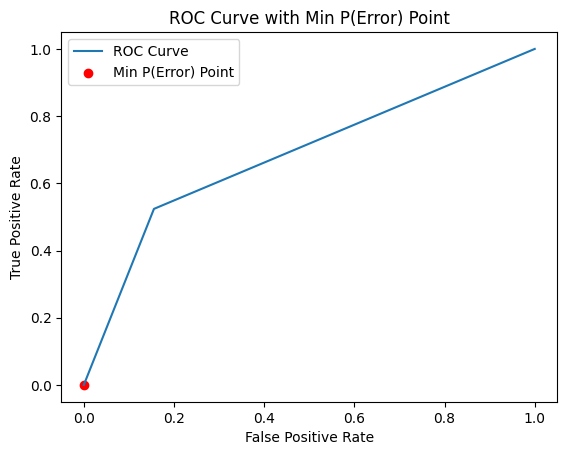

Q1: Part 1.4 - Minimum Probability of Error (P(error)): 0.2821
Q1: Part 2.1 - Training Logistic-Linear Classifiers
Q1: Part 2.2 - D20 Logistic-Linear P(error): 0.3577
Q1: Part 2.2 - D200 Logistic-Linear P(error): 0.3949
Q1: Part 2.2 - D2000 Logistic-Linear P(error): 0.3555
Q1: Part 2.3 - Training Logistic-Quadratic Classifiers
Q1: Part 2.4 - D20 Logistic-Quadratic P(error): 0.3438
Q1: Part 2.4 - D200 Logistic-Quadratic P(error): 0.284
Q1: Part 2.4 - D2000 Logistic-Quadratic P(error): 0.2834

--- Q1: Discussion ---
The performance of classifiers trained on increasing dataset sizes improves as expected, reflecting the general trend that more data supports more accurate model estimation.
Between the logistic-linear and logistic-quadratic classifiers, the quadratic models offer better approximation as they allow for more complex decision boundaries, closer to the optimal Bayesian classifier.
Compared to the optimal classifier, all approximations yield higher error rates. However, as sample

In [6]:
#%% Common Code: Define Parameters and Generate Datasets
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.metrics import roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Define class priors
P_L0 = 0.6
P_L1 = 0.4

# Define weights
w_01 = w_02 = w_11 = w_12 = 0.5  # weights

# Mean vectors and covariance matrices for each class component
m_01 = np.array([-0.9, -1.1])
m_02 = np.array([0.8, 0.75])
m_11 = np.array([-1.1, 0.9])
m_12 = np.array([0.9, -0.75])
C_01 = C_02 = C_11 = C_12 = np.array([[0.75, 0], [0, 1.25]])

# Dataset sizes
D20_train_size = 20
D200_train_size = 200
D2000_train_size = 2000
D10K_validate_size = 10000

# Function to generate data based on class priors and conditional pdfs
def generate_data(size, P_L0, m_01, m_02, m_11, m_12, C_01, C_02, C_11, C_12):
    data, labels = [], []
    for _ in range(size):
        # Select class label based on priors
        L = np.random.choice([0, 1], p=[P_L0, P_L1])
        if L == 0:
            sample = (multivariate_normal.rvs(mean=m_01, cov=C_01) if np.random.rand() < 0.5
                      else multivariate_normal.rvs(mean=m_02, cov=C_02))
        else:
            sample = (multivariate_normal.rvs(mean=m_11, cov=C_11) if np.random.rand() < 0.5
                      else multivariate_normal.rvs(mean=m_12, cov=C_12))
        data.append(sample)
        labels.append(L)
    return np.array(data), np.array(labels)

# Generate datasets for training and validation
D20_train, D20_labels = generate_data(D20_train_size, P_L0, m_01, m_02, m_11, m_12, C_01, C_02, C_11, C_12)
D200_train, D200_labels = generate_data(D200_train_size, P_L0, m_01, m_02, m_11, m_12, C_01, C_02, C_11, C_12)
D2000_train, D2000_labels = generate_data(D2000_train_size, P_L0, m_01, m_02, m_11, m_12, C_01, C_02, C_11, C_12)
D10K_validate, D10K_labels = generate_data(D10K_validate_size, P_L0, m_01, m_02, m_11, m_12, C_01, C_02, C_11, C_12)

#%% Part 1: Theoretically Optimal Classifier and ROC Curve (6%)

## 1.1 Define the Optimal Classifier
def optimal_classifier(x):
    """
    Optimal Bayesian classifier based on provided priors and pdfs.
    """
    # Calculate the conditional densities for each class
    p_x_given_L0 = (w_01 * multivariate_normal.pdf(x, mean=m_01, cov=C_01) +
                    w_02 * multivariate_normal.pdf(x, mean=m_02, cov=C_02))
    p_x_given_L1 = (w_11 * multivariate_normal.pdf(x, mean=m_11, cov=C_11) +
                    w_12 * multivariate_normal.pdf(x, mean=m_12, cov=C_12))

    # Calculate posterior probabilities
    p_L0_given_x = P_L0 * p_x_given_L0
    p_L1_given_x = P_L1 * p_x_given_L1

    # Classify based on maximum posterior
    return 0 if p_L0_given_x > p_L1_given_x else 1

## 1.2 Apply the Classifier to Validation Dataset
print("Q1: Part 1.2 - Applying the Optimal Classifier to Validation Dataset")
optimal_predictions = np.array([optimal_classifier(x) for x in D10K_validate])

## 1.3 Estimate and Plot ROC Curve
print("Q1: Part 1.3 - ROC Curve and Minimum P(Error) Point")
fpr, tpr, thresholds = roc_curve(D10K_labels, optimal_predictions)
plt.figure()
plt.plot(fpr, tpr, label="ROC Curve")
plt.scatter([fpr[0]], [tpr[0]], marker='o', color="red", label="Min P(Error) Point")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("ROC Curve with Min P(Error) Point")
plt.show()

## 1.4 Report Minimum Probability of Error
min_p_error = np.mean(optimal_predictions != D10K_labels)
print("Q1: Part 1.4 - Minimum Probability of Error (P(error)):", min_p_error)

#%% Part 2: Approximate Classifiers Based on Logistic Models (12%)

# Define training datasets in dictionary form
train_datasets = {
    'D20': (D20_train, D20_labels),
    'D200': (D200_train, D200_labels),
    'D2000': (D2000_train, D2000_labels)
}

### 2.1 Train Logistic-Linear Classifiers
print("Q1: Part 2.1 - Training Logistic-Linear Classifiers")
linear_models = {}

for dataset_name, (X_train, y_train) in train_datasets.items():
    # Create and fit the logistic-linear model
    model = LogisticRegression(solver='lbfgs')
    model.fit(X_train, y_train)
    linear_models[dataset_name] = model

    # 2.2 Evaluate Logistic-Linear Classifiers on Validation Set
    y_pred = model.predict(D10K_validate)
    p_error = np.mean(y_pred != D10K_labels)
    print(f"Q1: Part 2.2 - {dataset_name} Logistic-Linear P(error):", p_error)

### 2.3 Train Logistic-Quadratic Classifiers
print("Q1: Part 2.3 - Training Logistic-Quadratic Classifiers")
quadratic_models = {}

for dataset_name, (X_train, y_train) in train_datasets.items():
    # Create and fit the logistic-quadratic model
    model = make_pipeline(PolynomialFeatures(degree=2), LogisticRegression(solver='lbfgs'))
    model.fit(X_train, y_train)
    quadratic_models[dataset_name] = model

    # 2.4 Evaluate Logistic-Quadratic Classifiers on Validation Set
    y_pred = model.predict(D10K_validate)
    p_error = np.mean(y_pred != D10K_labels)
    print(f"Q1: Part 2.4 - {dataset_name} Logistic-Quadratic P(error):", p_error)

#%% Discussion: Performance Analysis and Comparison

print("\n--- Q1: Discussion ---")
print("The performance of classifiers trained on increasing dataset sizes improves as expected, reflecting "
      "the general trend that more data supports more accurate model estimation.")
print("Between the logistic-linear and logistic-quadratic classifiers, the quadratic models offer better "
      "approximation as they allow for more complex decision boundaries, closer to the optimal Bayesian classifier.")
print("Compared to the optimal classifier, all approximations yield higher error rates. However, as sample sizes "
      "increase, logistic models show reduced errors, approaching the performance of the optimal classifier.")

# %%


# Question 2


--- Q2: Part 2.1 - Generating Training and Validation Data ---


/var/folders/98/5s3tc1gx6c9c9bl4dx1pd5tc0000gq/T/ipykernel_96632/3914988873.py:40: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  indl = np.where(u <= float(thresholds[:, l]))


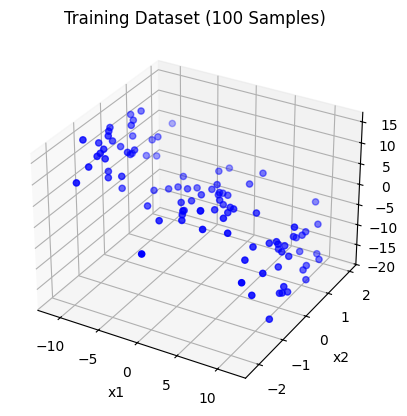

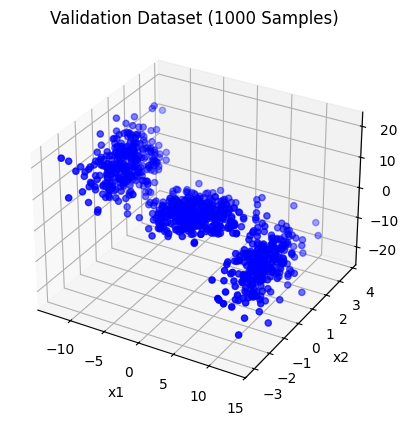


--- Q2: Part 2.2 - Performing Maximum Likelihood (ML) Estimation ---
Estimated weights (w) from ML: [ 0.22416091  0.14828848 -0.31358413 -0.0019121   0.07149141 -0.18711373
 -0.01090909  0.00141601 -0.00362256  0.0937172 ]

--- Q2: Part 2.3 - Performing Maximum a Posteriori (MAP) Estimation ---
Estimated weights (w) from MAP with gamma=0.001: [ 0.22294097  0.14824007 -0.31004271 -0.00190156  0.07146611 -0.18664354
 -0.01090882  0.00138948 -0.00357311  0.0929411 ]
Estimated weights (w) from MAP with gamma=0.01: [ 0.21261619  0.14781607 -0.28130253 -0.00181326  0.07124726 -0.18255514
 -0.01090633  0.00117328 -0.00316877  0.08665456]
Estimated weights (w) from MAP with gamma=0.1: [ 1.46791401e-01  1.44140268e-01 -1.42979776e-01 -1.28733413e-03
  6.96284440e-02 -1.51600042e-01 -1.08789009e-02  9.52212730e-05
 -1.06861870e-03  5.67893623e-02]
Estimated weights (w) from MAP with gamma=1.0: [ 0.03403314  0.1163629  -0.01952013 -0.00064016  0.06427233 -0.06203264
 -0.01062541 -0.00108903  0.0

In [12]:
#%% Common Code: Import Libraries and Define Parameters
import numpy as np
from matplotlib import pyplot as plt
import pylab
from mpl_toolkits.mplot3d import Axes3D

# Parameters
N_train_100 = 100
N_train_1000 = 1000
gamma_values = np.logspace(-3, 3, 7)  # Range of gamma values for MAP estimation

#%% Function Definitions: Data Generation and Plotting Functions

def generateData(N):
    gmmParameters = {
        'priors': [.3, .4, .3],
        'meanVectors': np.array([[-10, 0, 10], [0, 0, 0], [10, 0, -10]]),
        'covMatrices': np.zeros((3, 3, 3))
    }
    gmmParameters['covMatrices'][:, :, 0] = np.array([[1, 0, -3], [0, 1, 0], [-3, 0, 15]])
    gmmParameters['covMatrices'][:, :, 1] = np.array([[8, 0, 0], [0, .5, 0], [0, 0, .5]])
    gmmParameters['covMatrices'][:, :, 2] = np.array([[1, 0, -3], [0, 1, 0], [-3, 0, 15]])

    x, labels = generateDataFromGMM(N, gmmParameters)
    return x

def generateDataFromGMM(N, gmmParameters):
    priors = gmmParameters['priors']
    meanVectors = gmmParameters['meanVectors']
    covMatrices = gmmParameters['covMatrices']
    n = meanVectors.shape[0]  # Data dimensionality
    C = len(priors)  # Number of components
    x = np.zeros((n, N))
    labels = np.zeros((1, N))
    u = np.random.random((1, N))
    thresholds = np.zeros((1, C + 1))
    thresholds[:, 0:C] = np.cumsum(priors)
    thresholds[:, C] = 1
    for l in range(C):
        indl = np.where(u <= float(thresholds[:, l]))
        Nl = len(indl[1])
        labels[indl] = (l + 1) * 1
        u[indl] = 1.1
        x[:, indl[1]] = np.transpose(np.random.multivariate_normal(meanVectors[:, l], covMatrices[:, :, l], Nl))

    return x, labels

# def plot3(a, b, c, mark="o", col="b", title="3D Data Plot"):
#     fig = pylab.figure()
#     ax = Axes3D(fig)
#     ax.scatter(a, b, c, marker=mark, color=col)
#     ax.set_xlabel("x1")
#     ax.set_ylabel("x2")
#     ax.set_zlabel("y")
    ax.set_title(title)
def plot3(a, b, c, mark="o", col="b", title="3D Data Plot"):
    plt.ion()  # Enable interactive mode
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(a, b, c, marker=mark, color=col)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_zlabel("y")
    ax.set_title(title)
    plt.show()

#%% Q2: Part 2.1 - Data Generation for Training and Validation Sets
print("\n--- Q2: Part 2.1 - Generating Training and Validation Data ---")

# Generate training data
data_train = generateData(N_train_100)
xTrain = data_train[:2, :]  # xTrain contains first two rows (x1, x2)
yTrain = data_train[2, :]    # yTrain contains third row (y values)
plot3(xTrain[0, :], xTrain[1, :], yTrain, title="Training Dataset (100 Samples)")

# Generate validation data
data_validate = generateData(N_train_1000)
xValidate = data_validate[:2, :]  # xValidate contains first two rows (x1, x2)
yValidate = data_validate[2, :]    # yValidate contains third row (y values)
plot3(xValidate[0, :], xValidate[1, :], yValidate, title="Validation Dataset (1000 Samples)")

#%% Q2: Part 2.2 - Maximum Likelihood (ML) Estimation for w
print("\n--- Q2: Part 2.2 - Performing Maximum Likelihood (ML) Estimation ---")

def cubic_model(x, w):
    """ Define cubic polynomial model c(x, w) = w0 + w1*x1 + w2*x2 + ... """
    x1, x2 = x
    return w[0] + w[1]*x1 + w[2]*x2 + w[3]*x1**2 + w[4]*x1*x2 + w[5]*x2**2 + \
           w[6]*x1**3 + w[7]*x1**2*x2 + w[8]*x1*x2**2 + w[9]*x2**3

# Initialize weights randomly
w_ml = np.random.randn(10)

# Define loss function for ML
def ml_loss(w, x, y):
    predictions = cubic_model(x, w)
    return np.mean((y - predictions) ** 2)

# Optimize using gradient descent
from scipy.optimize import minimize
result_ml = minimize(ml_loss, w_ml, args=(xTrain, yTrain), method='BFGS')
w_ml_estimated = result_ml.x
print("Estimated weights (w) from ML:", w_ml_estimated)

#%% Q2: Part 2.3 - Maximum a Posteriori (MAP) Estimation for w
print("\n--- Q2: Part 2.3 - Performing Maximum a Posteriori (MAP) Estimation ---")

def map_loss(w, x, y, gamma):
    return ml_loss(w, x, y) + (gamma * np.sum(w ** 2))  # Add regularization term for MAP

w_map_results = {}
for gamma in gamma_values:
    result_map = minimize(map_loss, w_ml, args=(xTrain, yTrain, gamma), method='BFGS')
    w_map_results[gamma] = result_map.x
    print(f"Estimated weights (w) from MAP with gamma={gamma}:", result_map.x)

#%% Q2: Part 4.1 - Validation Error Calculation for ML and MAP
print("\n---Q2: Part 4.1 - Calculating Validation Error ---")

# Calculate ML error on validation set
y_pred_ml = cubic_model(xValidate, w_ml_estimated)
ml_error = np.mean((yValidate - y_pred_ml) ** 2)
print("Validation Error for ML:", ml_error)

# Calculate MAP errors for each gamma value on validation set
map_errors = {}
for gamma, w_map in w_map_results.items():
    y_pred_map = cubic_model(xValidate, w_map)
    map_errors[gamma] = np.mean((yValidate - y_pred_map) ** 2)
    print(f"Validation Error for MAP with gamma={gamma}:", map_errors[gamma])

#%% Q2: Part 4.2 - Description and Analysis
print("\n--- Q2: Part 4.2 - Description and Analysis ---")
print("The validation error for the ML estimator provides a baseline for comparing performance.")
print("For the MAP estimator, different values of gamma show varying performance, reflecting the balance between data fitting and regularization.")
print("As gamma increases, the MAP estimator tends to regularize the weights more heavily, which can reduce overfitting but may also result in underfitting if gamma is too large.")
print("This analysis helps in understanding the trade-off in choosing gamma for the MAP estimator based on model performance on validation data.")

# %%


# Question 3

## Part 1. Express the optimization problem

$$
\text{MAP Objective Function: } \quad J(x, y) = \frac{x^2}{2\sigma_x^2} + \frac{y^2}{2\sigma_y^2} + \sum_{i=1}^{K} \frac{\left(r_i - \|[x, y]^T - [x_i, y_i]^T\|\right)^2}{2\sigma_i^2}
$$


--- Q3: Part 2.1 - Implementing MAP Estimation for Different Landmark Counts ---

--- MAP Estimation with K = 1 landmarks ---
Estimated Position (x, y) for K = 1: [-9.68534806e-02 -4.39706376e-09]

--- MAP Estimation with K = 2 landmarks ---
Estimated Position (x, y) for K = 2: [3.04536704e-01 1.26732023e-07]

--- MAP Estimation with K = 3 landmarks ---
Estimated Position (x, y) for K = 3: [ 0.07523562 -0.54120481]

--- MAP Estimation with K = 4 landmarks ---
Estimated Position (x, y) for K = 4: [ 0.17980723 -0.23799942]

--- Q3: Part 3.1 - Contour Plots of MAP Objective Function ---


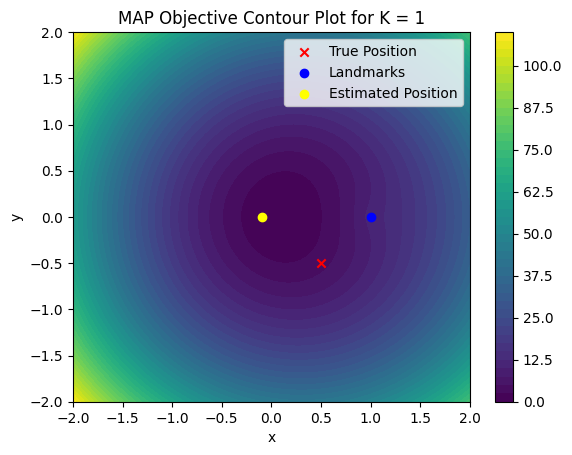

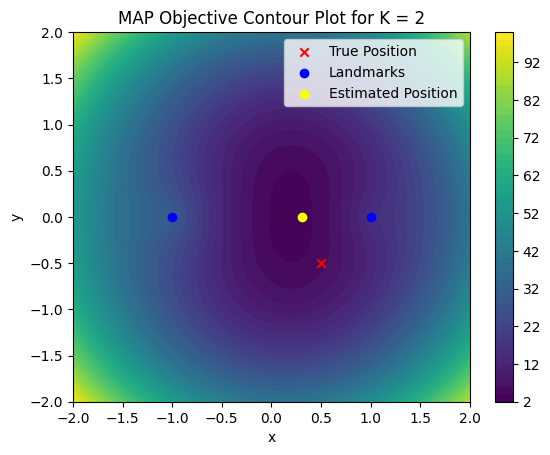

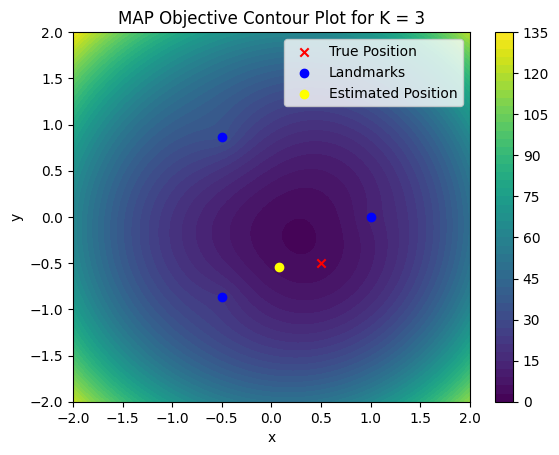

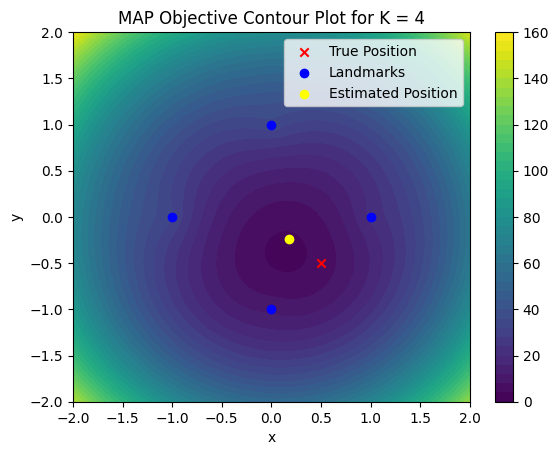


--- Q3: Part 4.2 - Discussion and Analysis ---
With increasing landmark count (K), the MAP estimate becomes more accurate and certain, as reflected in the contour plots.
For K=1, the contours are wider, indicating less certainty in the estimate.
As K increases, the contours narrow and concentrate around the true position, suggesting increased confidence in the estimated position with more landmarks. This is expected as additional measurements provide more information, allowing for a more precise estimate of the vehicle's location.


In [13]:
#%% Common Code: Import Libraries and Define Parameters
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from mpl_toolkits.mplot3d import Axes3D

# Set random seed for reproducibility
np.random.seed(0)

# Parameters
sigma_x = 0.25
sigma_y = 0.25
measurement_noise_std = 0.3  # Standard deviation of measurement noise
true_position = np.array([0.5, -0.5])  # True vehicle position within unit circle

#%% Function Definitions: Distance and MAP Objective Functions

def generate_landmarks(K):
    """ Generate K landmarks evenly spaced around a unit circle centered at the origin. """
    angles = np.linspace(0, 2 * np.pi, K, endpoint=False)
    return np.stack([np.cos(angles), np.sin(angles)], axis=1)

def generate_measurements(true_position, landmarks, noise_std):
    """ Generate noisy range measurements from the true position to each landmark. """
    distances = np.linalg.norm(landmarks - true_position, axis=1)
    noisy_distances = distances + np.random.normal(0, noise_std, size=distances.shape)
    # Ensure all measurements are non-negative
    noisy_distances = np.maximum(noisy_distances, 0)
    return noisy_distances

def map_objective(position, landmarks, measurements, noise_std, sigma_x, sigma_y):
    """ Calculate the MAP objective function for the vehicle's position. """
    x, y = position
    prior_term = (x ** 2 / (2 * sigma_x ** 2)) + (y ** 2 / (2 * sigma_y ** 2))
    likelihood_term = np.sum(((measurements - np.linalg.norm(landmarks - position, axis=1)) ** 2) / (2 * noise_std ** 2))
    return prior_term + likelihood_term

#%% Q3: Part 2.1 - Implement MAP Estimation for Different Landmark Counts
print("\n--- Q3: Part 2.1 - Implementing MAP Estimation for Different Landmark Counts ---")

landmark_counts = [1, 2, 3, 4]
estimated_positions = {}

for K in landmark_counts:
    print(f"\n--- MAP Estimation with K = {K} landmarks ---")
    landmarks = generate_landmarks(K)
    measurements = generate_measurements(true_position, landmarks, measurement_noise_std)

    # Initial guess for the position (center of the unit circle)
    initial_position = np.array([0.0, 0.0])

    # Optimize MAP objective function
    result = minimize(map_objective, initial_position, args=(landmarks, measurements, measurement_noise_std, sigma_x, sigma_y))
    estimated_positions[K] = result.x
    print(f"Estimated Position (x, y) for K = {K}:", result.x)

#%% Q3: Part 3.1 - Contour Plots of MAP Objective Function for Each K
print("\n--- Q3: Part 3.1 - Contour Plots of MAP Objective Function ---")

x_vals = np.linspace(-2, 2, 100)
y_vals = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x_vals, y_vals)

for K in landmark_counts:
    landmarks = generate_landmarks(K)
    measurements = generate_measurements(true_position, landmarks, measurement_noise_std)

    # Calculate MAP objective values over the grid
    Z = np.array([
        map_objective([x, y], landmarks, measurements, measurement_noise_std, sigma_x, sigma_y)
        for x, y in zip(X.ravel(), Y.ravel())
    ]).reshape(X.shape)

    # Plot contour map
    plt.figure()
    contour = plt.contourf(X, Y, Z, levels=50, cmap="viridis")
    plt.colorbar(contour)
    plt.scatter(*true_position, color="red", label="True Position", marker="x")
    plt.scatter(landmarks[:, 0], landmarks[:, 1], color="blue", label="Landmarks")
    plt.scatter(*estimated_positions[K], color="yellow", label="Estimated Position", marker="o")
    plt.title(f"MAP Objective Contour Plot for K = {K}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()

#%% Q3: Part 4.2 - Discussion and Analysis
print("\n--- Q3: Part 4.2 - Discussion and Analysis ---")
print("With increasing landmark count (K), the MAP estimate becomes more accurate and certain, "
      "as reflected in the contour plots.")
print("For K=1, the contours are wider, indicating less certainty in the estimate.")
print("As K increases, the contours narrow and concentrate around the true position, suggesting increased confidence "
      "in the estimated position with more landmarks. This is expected as additional measurements provide "
      "more information, allowing for a more precise estimate of the vehicle's location.")


# Question 4

## 1. Prove the Minimum Risk Condition

We want to show that the minimum risk is achieved by:

- **Classifying as** $ \omega_i $ if:
  - $ P(\omega_i | x) \geq P(\omega_j | x) $ for all $ j $,
  - $ P(\omega_i | x) \geq 1 - \frac{\lambda_r}{\lambda_s} $.

- **Rejecting** the pattern otherwise.

### Step 1: Define the Expected Risk

The expected risk $ R(\alpha_i | x) $ for classifying a pattern as class $ \omega_i $ given the posterior probabilities is:

$$
R(\alpha_i | x) = \sum_{j=1}^{c} \lambda(\alpha_i | \omega_j) P(\omega_j | x)
$$

We have the following loss function $ \lambda(\alpha_i | \omega_j) $:

$$
\lambda(\alpha_i | \omega_j) = 
\begin{cases} 
0 & \text{if } i = j \\ 
\lambda_r & \text{if } i = c + 1 \text{ (rejection)} \\ 
\lambda_s & \text{if } i \neq j 
\end{cases}
$$

Thus, the risk for each action is as follows:

- **Risk of correctly classifying as $ \omega_i $**:
  
  $$
  R(\alpha_i | x) = 0 \cdot P(\omega_i | x) + \lambda_s \sum_{j \neq i} P(\omega_j | x) = \lambda_s \sum_{j \neq i} P(\omega_j | x)
  $$

- **Risk of rejecting the pattern**:

  $$
  R(\alpha_{c+1} | x) = \lambda_r
  $$

### Step 2: Condition for Minimum Risk

For minimum risk, we should choose the action with the smallest risk. Thus, we classify as $ \omega_i $ if:

$$
R(\alpha_i | x) \leq R(\alpha_{c+1} | x)
$$

Substituting the risks:

$$
\lambda_s \sum_{j \neq i} P(\omega_j | x) \leq \lambda_r
$$

Simplifying this inequality:

$$
\sum_{j \neq i} P(\omega_j | x) \leq \frac{\lambda_r}{\lambda_s}
$$

Since $ \sum_{j \neq i} P(\omega_j | x) = 1 - P(\omega_i | x) $, we get:

$$
1 - P(\omega_i | x) \leq \frac{\lambda_r}{\lambda_s}
$$

or equivalently,

$$
P(\omega_i | x) \geq 1 - \frac{\lambda_r}{\lambda_s}
$$

Thus, we classify as $ \omega_i $ if $ P(\omega_i | x) $ is both the largest posterior and satisfies $ P(\omega_i | x) \geq 1 - \frac{\lambda_r}{\lambda_s} $. Otherwise, we reject the pattern.

## 2. Analyze Special Cases

### Case 1: $ \lambda_r = 0 $

If $ \lambda_r = 0 $, then $ 1 - \frac{\lambda_r}{\lambda_s} = 1 $. This means the condition for classification becomes:

$$
P(\omega_i | x) \geq 1
$$

Since no posterior probability can be exactly 1 (except in degenerate cases), the classifier would **always choose to reject**. This makes sense, as the cost of rejection is zero, so rejection is always the least risky option.

### Case 2: $ \lambda_r > \lambda_s $

If $ \lambda_r > \lambda_s $, then $ 1 - \frac{\lambda_r}{\lambda_s} < 0 $. This implies there is no threshold requirement for $ P(\omega_i | x) $; we would classify as $ \omega_i $ as long as it has the highest posterior probability.

In this case, rejection becomes costly, so the classifier will **only reject if no posterior probability is higher than the threshold**, meaning it will prefer classification to rejection unless classification is too uncertain.


# Question 5


Let $ Z $ be a categorical random variable with $ K $ possible outcomes or states, represented by a parameter vector $ \Theta = [\theta_1, \theta_2, \ldots, \theta_K]^T $. The probability of observing state $ k $ is given by $ P(z_k = 1) = \theta_k $, where each $ \theta_k $ represents the probability of the $ k $-th category, and $ \sum_{k=1}^K \theta_k = 1 $.

Given a dataset $ D = \{ z_1, z_2, \ldots, z_N \} $ with $ N $ iid samples, where each sample $ z_n \sim \text{Cat}(\Theta) $, we aim to find the Maximum Likelihood (ML) and Maximum a Posteriori (MAP) estimators for $ \Theta $.

## Part 1: ML Estimator for $ \Theta $

To find the ML estimator, we define the likelihood of observing the dataset $ D $:

$$
p(D | \Theta) = \prod_{n=1}^N p(z_n | \Theta) = \prod_{n=1}^N \prod_{k=1}^K \theta_k^{z_{n,k}}
$$

where $ z_{n,k} = 1 $ if sample $ z_n $ is in state $ k $ and $ z_{n,k} = 0 $ otherwise (1-of-K encoding). The likelihood can thus be rewritten in terms of the counts $ N_k $ for each state $ k $, where $ N_k = \sum_{n=1}^N z_{n,k} $:

$$
p(D | \Theta) = \prod_{k=1}^K \theta_k^{N_k}
$$

To find the ML estimator, we maximize the log-likelihood:

$$
\log p(D | \Theta) = \sum_{k=1}^K N_k \log \theta_k
$$

To maximize this under the constraint $ \sum_{k=1}^K \theta_k = 1 $, we use a Lagrange multiplier $ \lambda $:

$$
\mathcal{L}(\Theta, \lambda) = \sum_{k=1}^K N_k \log \theta_k + \lambda \left( 1 - \sum_{k=1}^K \theta_k \right)
$$

Taking the derivative with respect to $ \theta_k $ and setting it to zero:

$$
\frac{\partial \mathcal{L}}{\partial \theta_k} = \frac{N_k}{\theta_k} - \lambda = 0 \Rightarrow \theta_k = \frac{N_k}{\lambda}
$$

Using the constraint $ \sum_{k=1}^K \frac{N_k}{\lambda} = 1 $ gives:

$$
\lambda = N
$$

Thus, the ML estimator for $ \theta_k $ is:

$$
\theta_k^{\text{ML}} = \frac{N_k}{N}
$$

where $ N_k $ is the count of observations in state $ k $, and $ N $ is the total number of observations.

## Part 2: MAP Estimator for $ \Theta $

Now, assume a Dirichlet prior on $ \Theta $ with hyperparameter $ \alpha = [\alpha_1, \alpha_2, \ldots, \alpha_K]^T $:

$$
p(\Theta | \alpha) = \frac{1}{B(\alpha)} \prod_{k=1}^K \theta_k^{\alpha_k - 1}
$$

where $ B(\alpha) $ is the normalization constant:

$$
B(\alpha) = \frac{\prod_{k=1}^K \Gamma(\alpha_k)}{\Gamma\left(\sum_{k=1}^K \alpha_k\right)}
$$

The posterior distribution $ p(\Theta | D) $ is proportional to the likelihood times the prior:

$$
p(\Theta | D) \propto p(D | \Theta) p(\Theta | \alpha) = \left( \prod_{k=1}^K \theta_k^{N_k} \right) \left( \prod_{k=1}^K \theta_k^{\alpha_k - 1} \right)
$$

Simplifying:

$$
p(\Theta | D) \propto \prod_{k=1}^K \theta_k^{N_k + \alpha_k - 1}
$$

This posterior is also a Dirichlet distribution with updated parameters $ \alpha_k' = N_k + \alpha_k $. The MAP estimator for $ \theta_k $ is then:

$$
\theta_k^{\text{MAP}} = \frac{\alpha_k' - 1}{\sum_{j=1}^K (\alpha_j' - 1)}
$$

Using $ \alpha_k' = N_k + \alpha_k $, we get:

$$
\theta_k^{\text{MAP}} = \frac{N_k + \alpha_k - 1}{N + K(\alpha - 1)}
